# ERA5-Land Only: OL vs DA Bar Charts

This notebook is a simplified ERA5-Land-only version focused on standard OL/DA bar charts for:
- Surface SM
- Root-zone SM
- SCF
- SWE
- Snow Depth (SD)

Period selection:
- SM variables: first three sub-periods
- Snow variables: full period only


In [1]:

from pathlib import Path
import sys
import hashlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Resolve repo root
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "common/python/plotting/geospatial_plotting.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "common/python/plotting/geospatial_plotting.py").exists():
            REPO_ROOT = parent
            break

# ERA5-Land-only inputs
FN_DA = str(REPO_ROOT / "projects/era5_land/notebooks/ERA5L_vs_DAv8_M36_strict_summary.nc")
FN_OL = str(REPO_ROOT / "projects/era5_land/notebooks/ERA5L_vs_OLv8_M36_strict_summary.nc")
FILES = [FN_DA, FN_OL]

for fn in FILES:
    if not Path(fn).exists():
        raise FileNotFoundError(f"Missing input file: {fn}")

# Sub-periods + full period
PERIODS = [
    ("2000-06-01", "2007-05-31"),
    ("2007-06-01", "2015-03-31"),
    ("2015-04-01", "2024-05-31"),
    ("2000-06-01", "2024-05-31"),
]

MIN_PAIRS = 24
SNOW_EPS = 1e-6

USE_CACHE = True
REBUILD_CACHE = False
CACHE_DIR = REPO_ROOT / "cache" / "era5l_periodized_metrics_bars"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = REPO_ROOT / "projects/era5_land/notebooks/figures_era5l_bars"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("FN_DA:", FN_DA)
print("FN_OL:", FN_OL)
print("MIN_PAIRS:", MIN_PAIRS)
print("USE_CACHE:", USE_CACHE, "REBUILD_CACHE:", REBUILD_CACHE)


REPO_ROOT: /Users/amfox/Desktop/geosldas-analysis
FN_DA: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/ERA5L_vs_DAv8_M36_strict_summary.nc
FN_OL: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/ERA5L_vs_OLv8_M36_strict_summary.nc
MIN_PAIRS: 24
USE_CACHE: True REBUILD_CACHE: False


In [2]:

def anomalies_monthly(da, dim="time"):
    clim = da.groupby(f"{dim}.month").mean(dim=dim, skipna=True)
    return da.groupby(f"{dim}.month") - clim


def anom_metrics_monthly(a, b, dim="time", min_pairs=24):
    valid = xr.where(xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b), True, False)
    n = valid.sum(dim=dim)

    a_v = a.where(valid)
    b_v = b.where(valid)

    cov = (a_v * b_v).mean(dim=dim, skipna=True)
    var_a = (a_v**2).mean(dim=dim, skipna=True)
    var_b = (b_v**2).mean(dim=dim, skipna=True)

    denom = xr.ufuncs.sqrt(var_a * var_b)
    anomR = xr.where(denom > 0, cov / denom, np.nan)
    ubRMSE = xr.ufuncs.sqrt(((a_v - b_v) ** 2).mean(dim=dim, skipna=True))

    anomR = xr.where(n >= min_pairs, anomR, np.nan)
    ubRMSE = xr.where(n >= min_pairs, ubRMSE, np.nan)
    return anomR, ubRMSE


def corr_monthly(a, b, dim="time", min_pairs=24):
    valid = xr.where(xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b), True, False)
    n = valid.sum(dim=dim)

    a_v = a.where(valid)
    b_v = b.where(valid)

    a_dm = a_v - a_v.mean(dim=dim, skipna=True)
    b_dm = b_v - b_v.mean(dim=dim, skipna=True)

    cov = (a_dm * b_dm).mean(dim=dim, skipna=True)
    var_a = (a_dm**2).mean(dim=dim, skipna=True)
    var_b = (b_dm**2).mean(dim=dim, skipna=True)

    denom = xr.ufuncs.sqrt(var_a * var_b)
    R = xr.where(denom > 0, cov / denom, np.nan)
    R = xr.where(n >= min_pairs, R, np.nan)
    return R


def rmse_bias_monthly(a, b, dim="time", min_pairs=24):
    valid = xr.where(xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b), True, False)
    n = valid.sum(dim=dim)

    a_v = a.where(valid)
    b_v = b.where(valid)
    d = a_v - b_v

    rmse = xr.ufuncs.sqrt((d**2).mean(dim=dim, skipna=True))
    bias = d.mean(dim=dim, skipna=True)

    rmse = xr.where(n >= min_pairs, rmse, np.nan)
    bias = xr.where(n >= min_pairs, bias, np.nan)
    return rmse, bias


In [3]:

def _cache_file_for(fn, periods, min_pairs):
    payload = {
        "file": str(Path(fn).resolve()),
        "periods": periods,
        "min_pairs": int(min_pairs),
        "schema": "era5l_bars_v1",
    }
    key = hashlib.sha1(repr(payload).encode("utf-8")).hexdigest()[:12]
    base = Path(fn).name.replace(".nc", "")
    return CACHE_DIR / f"{base}__{key}.nc"


def _apply_era5l_no_snow_zero(ds):
    # ERA5-Land can encode no-snow as NaN in regridded inputs for SWE/SNWD.
    # Convert to 0 before metrics to match strict interpretation.
    out = ds.copy()
    for v in ("SWE_era", "SNWD_era"):
        if v in out:
            out[v] = out[v].fillna(0.0)
    return out


def compute_metrics_for_period(ds, t0, t1, min_pairs=24, snow_eps=1e-6):
    sub = xr.decode_cf(ds).sel(time=slice(pd.to_datetime(t0), pd.to_datetime(t1)))

    for v in ["SM_model", "SM_era", "SCF_model", "SCF_era"]:
        if v not in sub:
            raise KeyError(f"Required variable missing: {v}")

    mask_both = sub["mask_both"] if "mask_both" in sub else xr.full_like(sub["SM_model"], True, dtype=bool)

    # Surface SM
    sm_mod = sub["SM_model"].where(mask_both).astype("float64")
    sm_ref = sub["SM_era"].where(mask_both).astype("float64")
    sm_mod_an = anomalies_monthly(sm_mod)
    sm_ref_an = anomalies_monthly(sm_ref)
    anomR_sfc, ubRMSE_sfc = anom_metrics_monthly(sm_mod_an, sm_ref_an, min_pairs=min_pairs)
    R_sfc = corr_monthly(sm_mod, sm_ref, min_pairs=min_pairs)

    # Root-zone SM
    if ("RZ_model" in sub) and ("RZ_era" in sub):
        rz_mod = sub["RZ_model"].where(mask_both).astype("float64")
        rz_ref = sub["RZ_era"].where(mask_both).astype("float64")
        rz_mod_an = anomalies_monthly(rz_mod)
        rz_ref_an = anomalies_monthly(rz_ref)
        anomR_rz, ubRMSE_rz = anom_metrics_monthly(rz_mod_an, rz_ref_an, min_pairs=min_pairs)
        R_rz = corr_monthly(rz_mod, rz_ref, min_pairs=min_pairs)
    else:
        anomR_rz = xr.full_like(anomR_sfc, np.nan)
        ubRMSE_rz = xr.full_like(ubRMSE_sfc, np.nan)
        R_rz = xr.full_like(R_sfc, np.nan)

    # Fixed ever-snow mask over full record
    snow_any = ((ds["SCF_model"] > snow_eps) | (ds["SCF_era"] > snow_eps)).any(dim="time")
    snow_mask = xr.where(snow_any, True, False)

    # SCF
    scf_mod = sub["SCF_model"].where(snow_mask).astype("float64")
    scf_ref = sub["SCF_era"].where(snow_mask).astype("float64")
    scf_mod_an = anomalies_monthly(scf_mod)
    scf_ref_an = anomalies_monthly(scf_ref)
    anomR_scf, ubRMSE_scf = anom_metrics_monthly(scf_mod_an, scf_ref_an, min_pairs=min_pairs)
    R_scf = corr_monthly(scf_mod, scf_ref, min_pairs=min_pairs)
    rmse_scf, bias_scf = rmse_bias_monthly(scf_mod, scf_ref, min_pairs=min_pairs)

    # SWE
    if ("SWE_model" in sub) and ("SWE_era" in sub):
        swe_mod = sub["SWE_model"].where(snow_mask).astype("float64")
        swe_ref = sub["SWE_era"].where(snow_mask).astype("float64")
        swe_mod_an = anomalies_monthly(swe_mod)
        swe_ref_an = anomalies_monthly(swe_ref)
        anomR_swe, ubRMSE_swe = anom_metrics_monthly(swe_mod_an, swe_ref_an, min_pairs=min_pairs)
        R_swe = corr_monthly(swe_mod, swe_ref, min_pairs=min_pairs)
        rmse_swe, bias_swe = rmse_bias_monthly(swe_mod, swe_ref, min_pairs=min_pairs)
    else:
        anomR_swe = xr.full_like(anomR_sfc, np.nan)
        ubRMSE_swe = xr.full_like(ubRMSE_sfc, np.nan)
        R_swe = xr.full_like(R_sfc, np.nan)
        rmse_swe = xr.full_like(ubRMSE_sfc, np.nan)
        bias_swe = xr.full_like(anomR_sfc, np.nan)

    # Snow depth
    if ("SNWD_model" in sub) and ("SNWD_era" in sub):
        sd_mod = sub["SNWD_model"].where(snow_mask).astype("float64")
        sd_ref = sub["SNWD_era"].where(snow_mask).astype("float64")
        sd_mod_an = anomalies_monthly(sd_mod)
        sd_ref_an = anomalies_monthly(sd_ref)
        anomR_snwd, ubRMSE_snwd = anom_metrics_monthly(sd_mod_an, sd_ref_an, min_pairs=min_pairs)
        R_snwd = corr_monthly(sd_mod, sd_ref, min_pairs=min_pairs)
        rmse_snwd, bias_snwd = rmse_bias_monthly(sd_mod, sd_ref, min_pairs=min_pairs)
    else:
        anomR_snwd = xr.full_like(anomR_sfc, np.nan)
        ubRMSE_snwd = xr.full_like(ubRMSE_sfc, np.nan)
        R_snwd = xr.full_like(R_sfc, np.nan)
        rmse_snwd = xr.full_like(ubRMSE_sfc, np.nan)
        bias_snwd = xr.full_like(anomR_sfc, np.nan)

    return xr.Dataset(dict(
        R_sfc=R_sfc, anomR_sfc=anomR_sfc, ubRMSE_sfc=ubRMSE_sfc,
        R_rz=R_rz, anomR_rz=anomR_rz, ubRMSE_rz=ubRMSE_rz,
        R_scf=R_scf, anomR_scf=anomR_scf, ubRMSE_scf=ubRMSE_scf, rmse_scf=rmse_scf, bias_scf=bias_scf,
        R_swe=R_swe, anomR_swe=anomR_swe, ubRMSE_swe=ubRMSE_swe, rmse_swe=rmse_swe, bias_swe=bias_swe,
        R_snwd=R_snwd, anomR_snwd=anomR_snwd, ubRMSE_snwd=ubRMSE_snwd, rmse_snwd=rmse_snwd, bias_snwd=bias_snwd,
    ))


results = {}
per_labels = [f"{a}–{b}" for a, b in PERIODS]

for fn in FILES:
    cache_file = _cache_file_for(fn, PERIODS, MIN_PAIRS)
    if USE_CACHE and (not REBUILD_CACHE) and cache_file.exists():
        ds_all = xr.open_dataset(cache_file)
        results[fn] = ds_all
        print(f"Loaded cached periodized metrics: {cache_file}")
        continue

    ds = xr.open_dataset(fn)
    ds = _apply_era5l_no_snow_zero(ds)

    out_list = []
    for t0, t1 in PERIODS:
        out_list.append(compute_metrics_for_period(ds, t0, t1, min_pairs=MIN_PAIRS, snow_eps=SNOW_EPS))

    ds_all = xr.concat(out_list, dim=xr.DataArray(per_labels, dims=("period",), name="period"))
    results[fn] = ds_all

    if USE_CACHE:
        ds_all.to_netcdf(cache_file)
        print(f"Saved cached periodized metrics: {cache_file}")

print("Built datasets:")
for k, v in results.items():
    print(" ", Path(k).name, "dims:", dict(v.dims))

period_labels = [str(p) for p in next(iter(results.values())).coords["period"].values]
print("period_labels:", period_labels)


Saved cached periodized metrics: /Users/amfox/Desktop/geosldas-analysis/cache/era5l_periodized_metrics_bars/ERA5L_vs_DAv8_M36_strict_summary__27bfb9f0eb98.nc
Saved cached periodized metrics: /Users/amfox/Desktop/geosldas-analysis/cache/era5l_periodized_metrics_bars/ERA5L_vs_OLv8_M36_strict_summary__e5c443a4ae1b.nc
Built datasets:
  ERA5L_vs_DAv8_M36_strict_summary.nc dims: {'period': 4, 'y': 379, 'x': 964}
  ERA5L_vs_OLv8_M36_strict_summary.nc dims: {'period': 4, 'y': 379, 'x': 964}
period_labels: ['2000-06-01–2007-05-31', '2007-06-01–2015-03-31', '2015-04-01–2024-05-31', '2000-06-01–2024-05-31']


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_94817/3444920883.py:134: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(" ", Path(k).name, "dims:", dict(v.dims))


SM periods: ['2000-06-01–2007-05-31', '2007-06-01–2015-03-31', '2015-04-01–2024-05-31']
Snow period: ['2000-06-01–2024-05-31']


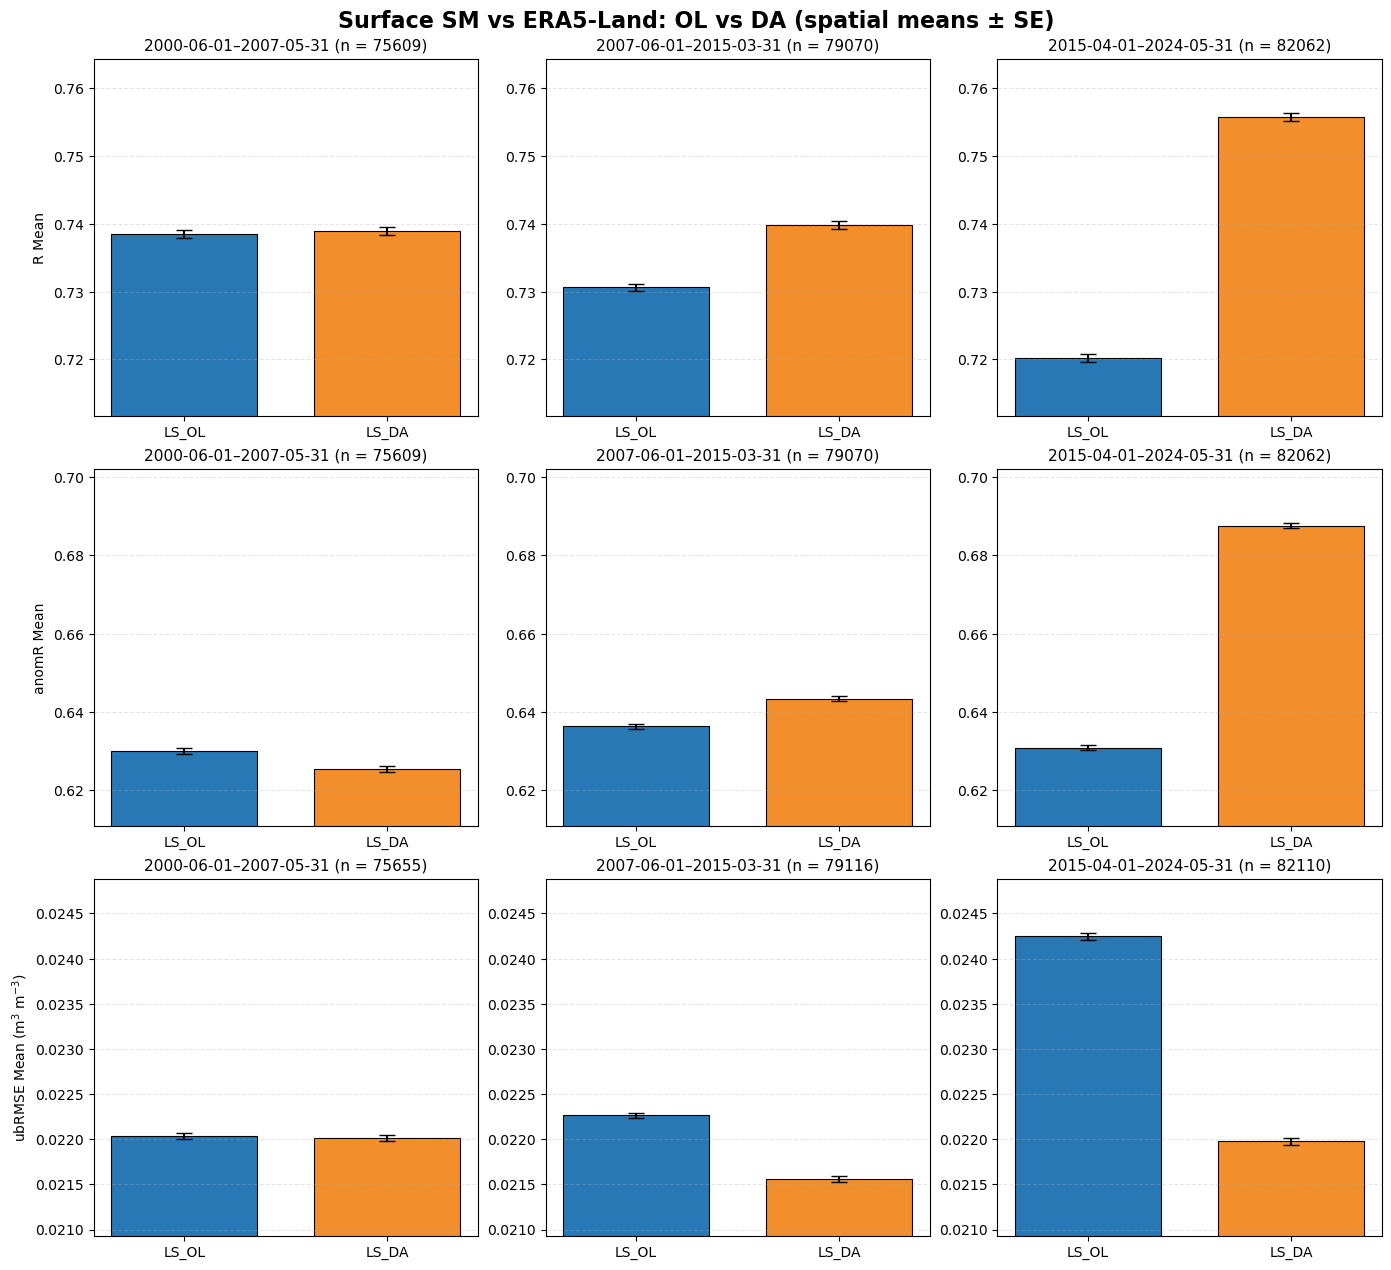

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_surface_sm_era5l_only.png


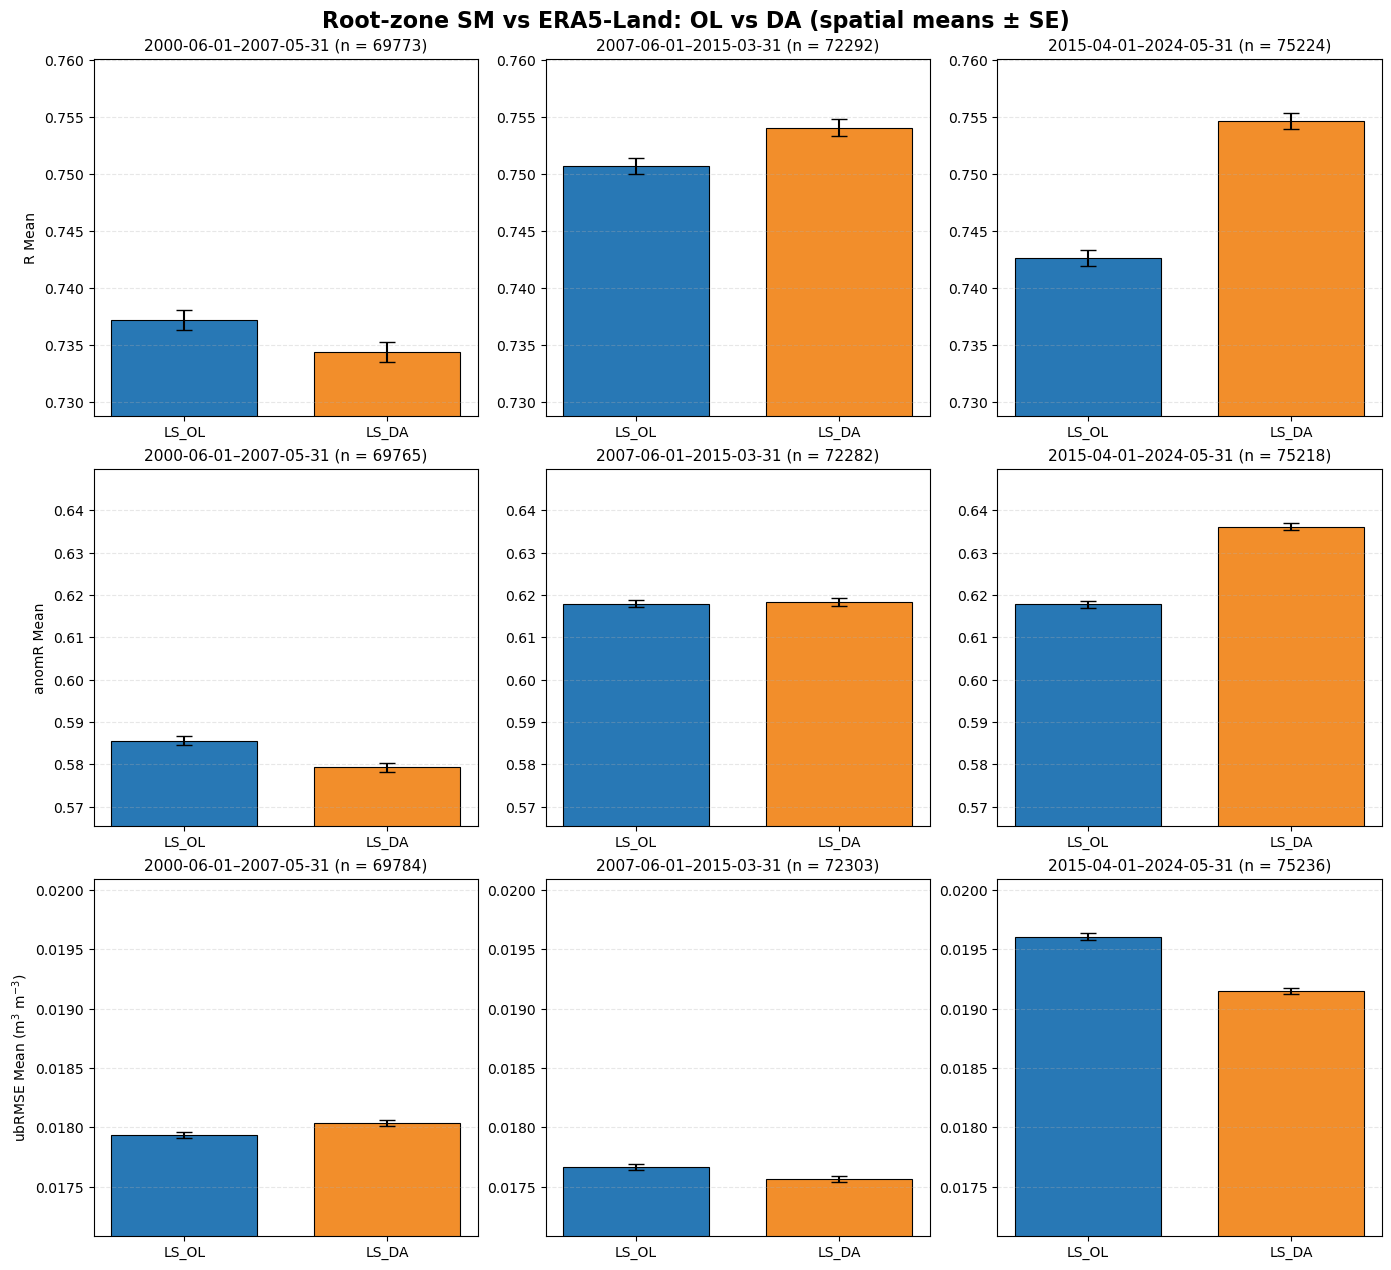

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_root-zone_sm_era5l_only.png


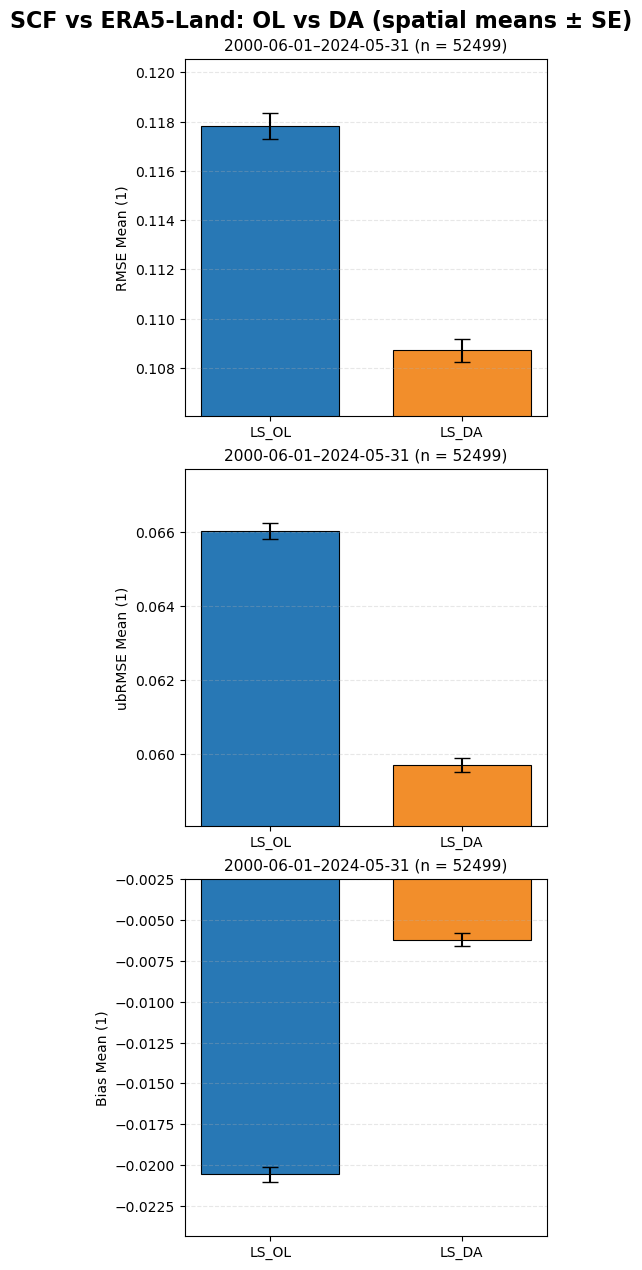

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_scf_era5l_only.png


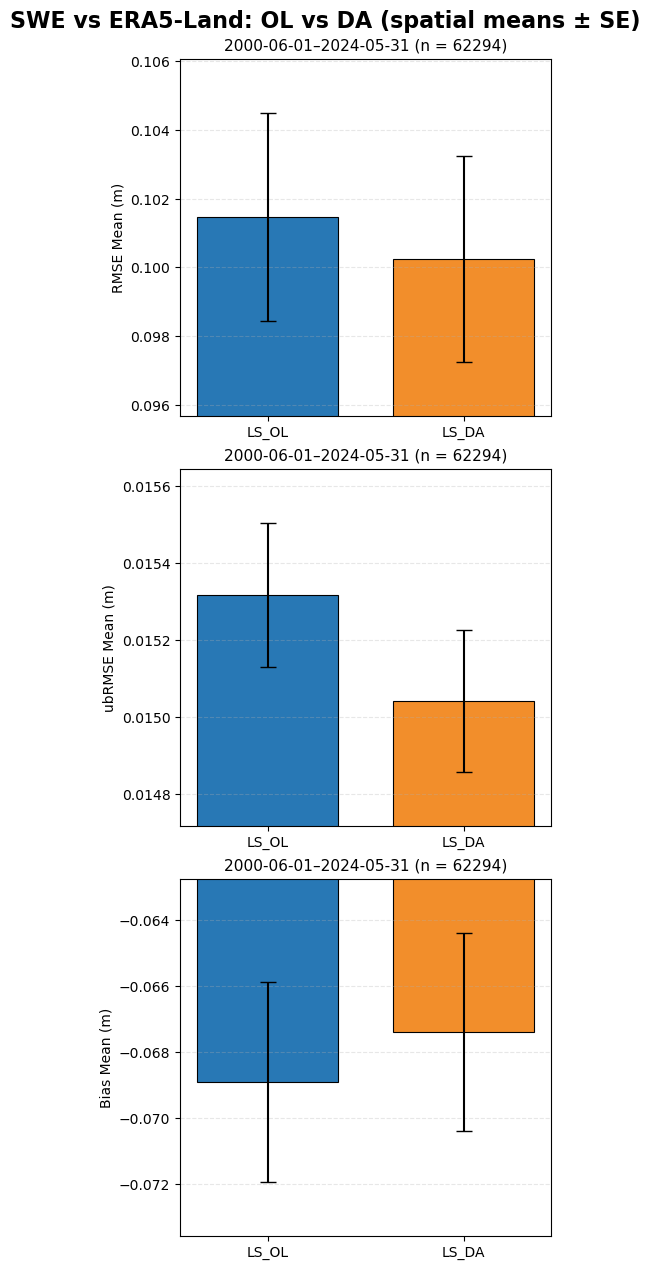

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_swe_era5l_only.png


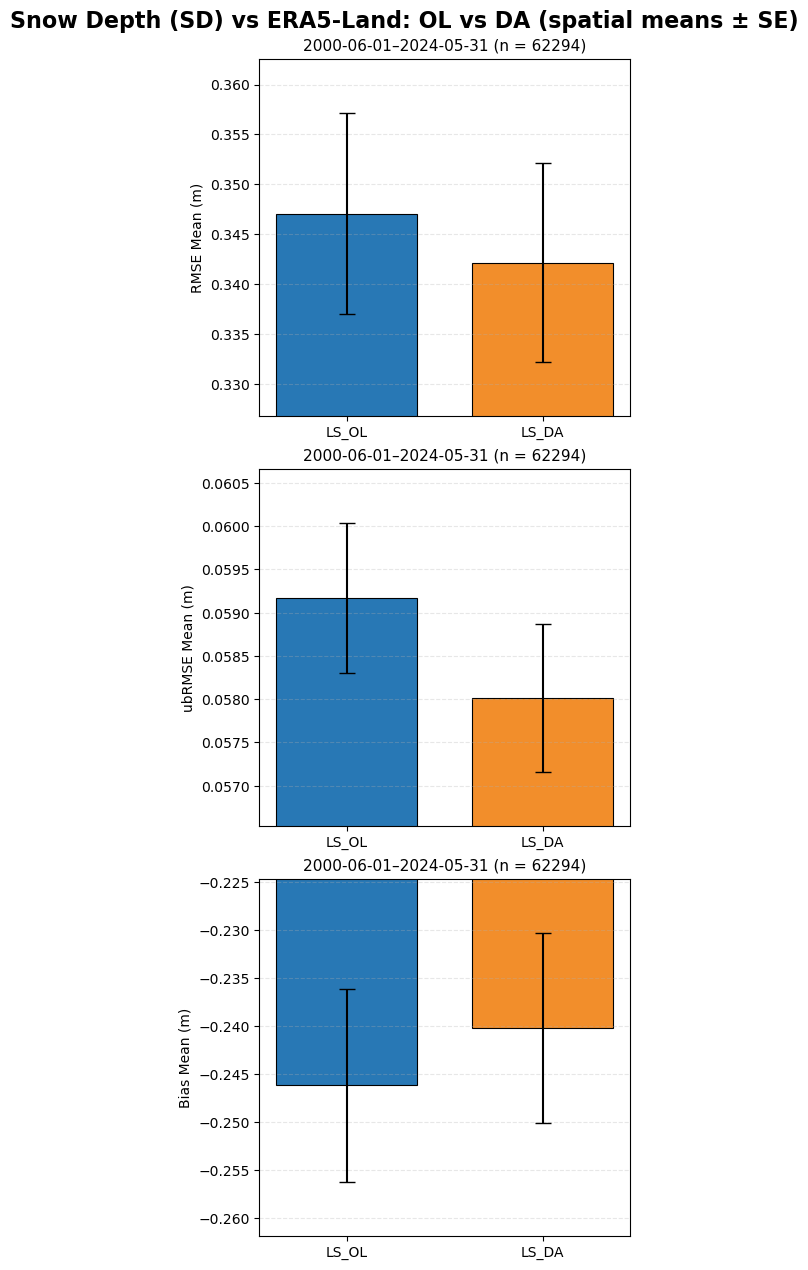

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_snow_depth_(sd)_era5l_only.png


In [4]:

# --- ERA5-Land-only OL/DA bar charts ---
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

label_for = {
    FN_OL: "OL",
    FN_DA: "DA",
}

COL_OL = "#2878B5"
COL_DA = "#F28E2B"

all_periods = [str(p) for p in next(iter(results.values())).coords["period"].values]
full_period = None
for p in all_periods:
    if ("2000-06-01" in p) and ("2024-05-31" in p):
        full_period = p
        break
if full_period is None:
    full_period = all_periods[-1]

sm_periods = all_periods[:3]
snow_periods = [full_period]

print("SM periods:", sm_periods)
print("Snow period:", snow_periods)


def mean_se_2d(da2d):
    v = np.asarray(da2d.values)
    m = np.isfinite(v)
    n = int(m.sum())
    if n == 0:
        return np.nan, np.nan, 0
    vals = v[m]
    mean = float(np.nanmean(vals))
    se = float(np.nanstd(vals, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
    return mean, se, n


def pooled_ylim(means_errs, pad=0.20, hard=(None, None)):
    lows, highs = [], []
    for mean, err in means_errs:
        if not np.isfinite(mean):
            continue
        e = 0.0 if not np.isfinite(err) else err
        lows.append(mean - e)
        highs.append(mean + e)

    if len(lows) == 0:
        return (0.0, 1.0)

    lo = float(np.nanmin(lows))
    hi = float(np.nanmax(highs))
    if hard[0] is not None:
        lo = max(lo, hard[0])
    if hard[1] is not None:
        hi = min(hi, hard[1])
    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo == hi):
        lo, hi = 0.0, 1.0

    span = hi - lo
    p = pad * (span if span > 0 else 1.0)
    return (lo - p, hi + p)


def collect_stats(metric_key, period_subset):
    stats = {str(per): {} for per in period_subset}
    for fn, ds_all in results.items():
        tag = label_for[fn]
        if metric_key not in ds_all:
            for per in period_subset:
                stats[str(per)][tag] = (np.nan, np.nan, 0)
            continue
        for per in period_subset:
            stats[str(per)][tag] = mean_se_2d(ds_all[metric_key].sel(period=per))
    return stats


def plot_group(group_name, metrics, ylabels, period_subset, hard_corr_bounds=None):
    nrows = 3
    ncols = len(period_subset)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.1 * nrows), constrained_layout=True)

    if ncols == 1:
        axes = np.asarray(axes).reshape(nrows, 1)

    fig.suptitle(
        f"{group_name} vs ERA5-Land: OL vs DA (spatial means ± SE)",
        fontsize=16,
        weight="bold",
        y=1.02,
    )

    common_lims = []
    for mkey in metrics:
        S = collect_stats(mkey, period_subset)
        all_me = []
        for per in period_subset:
            for tag in ("OL", "DA"):
                mean, se, _ = S[str(per)][tag]
                all_me.append((mean, se))
        if mkey.startswith(("R_", "anomR_")):
            hard = hard_corr_bounds if hard_corr_bounds is not None else (0.0, 1.0)
        else:
            hard = (None, None)
        common_lims.append(pooled_ylim(all_me, pad=0.22, hard=hard))

    for r, (mkey, ylabel) in enumerate(zip(metrics, ylabels)):
        S = collect_stats(mkey, period_subset)
        for c, per in enumerate(period_subset):
            ax = axes[r, c]
            ol_mean, ol_se, ol_n = S[str(per)]["OL"]
            da_mean, da_se, da_n = S[str(per)]["DA"]

            means = [ol_mean, da_mean]
            errs = [ol_se, da_se]
            ns = [ol_n, da_n]

            x = np.arange(2, dtype=float)
            ax.bar(
                x,
                means,
                width=0.72,
                color=[COL_OL, COL_DA],
                edgecolor="black",
                linewidth=0.8,
                yerr=errs,
                capsize=6,
            )

            ax.set_xticks(x)
            ax.set_xticklabels(["LS_OL", "LS_DA"])
            ax.set_ylim(*common_lims[r])
            ax.grid(axis="y", alpha=0.30, linestyle="--")
            ax.set_title(f"{per} (n = {min(ns)})", fontsize=11)

            if c == 0:
                ax.set_ylabel(ylabel)

    out_png = FIG_DIR / f"bars_{group_name.replace(' ', '_').lower()}_era5l_only.png"
    fig.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_png)


# Surface SM (3 periods)
plot_group(
    group_name="Surface SM",
    metrics=["R_sfc", "anomR_sfc", "ubRMSE_sfc"],
    ylabels=["R Mean", "anomR Mean", "ubRMSE Mean (m$^3$ m$^{-3}$)"],
    period_subset=sm_periods,
    hard_corr_bounds=(0.0, 1.0),
)

# Root-zone SM (3 periods)
plot_group(
    group_name="Root-zone SM",
    metrics=["R_rz", "anomR_rz", "ubRMSE_rz"],
    ylabels=["R Mean", "anomR Mean", "ubRMSE Mean (m$^3$ m$^{-3}$)"],
    period_subset=sm_periods,
    hard_corr_bounds=(0.0, 1.0),
)

# SCF (full period only)
plot_group(
    group_name="SCF",
    metrics=["rmse_scf", "ubRMSE_scf", "bias_scf"],
    ylabels=["RMSE Mean (1)", "ubRMSE Mean (1)", "Bias Mean (1)"],
    period_subset=snow_periods,
)

# SWE (full period only)
plot_group(
    group_name="SWE",
    metrics=["rmse_swe", "ubRMSE_swe", "bias_swe"],
    ylabels=["RMSE Mean (m)", "ubRMSE Mean (m)", "Bias Mean (m)"],
    period_subset=snow_periods,
)

# Snow Depth / SD (full period only)
plot_group(
    group_name="Snow Depth (SD)",
    metrics=["rmse_snwd", "ubRMSE_snwd", "bias_snwd"],
    ylabels=["RMSE Mean (m)", "ubRMSE Mean (m)", "Bias Mean (m)"],
    period_subset=snow_periods,
)


Using SM periods: ['2000-06-01–2007-05-31', '2007-06-01–2015-03-31', '2015-04-01–2024-05-31']


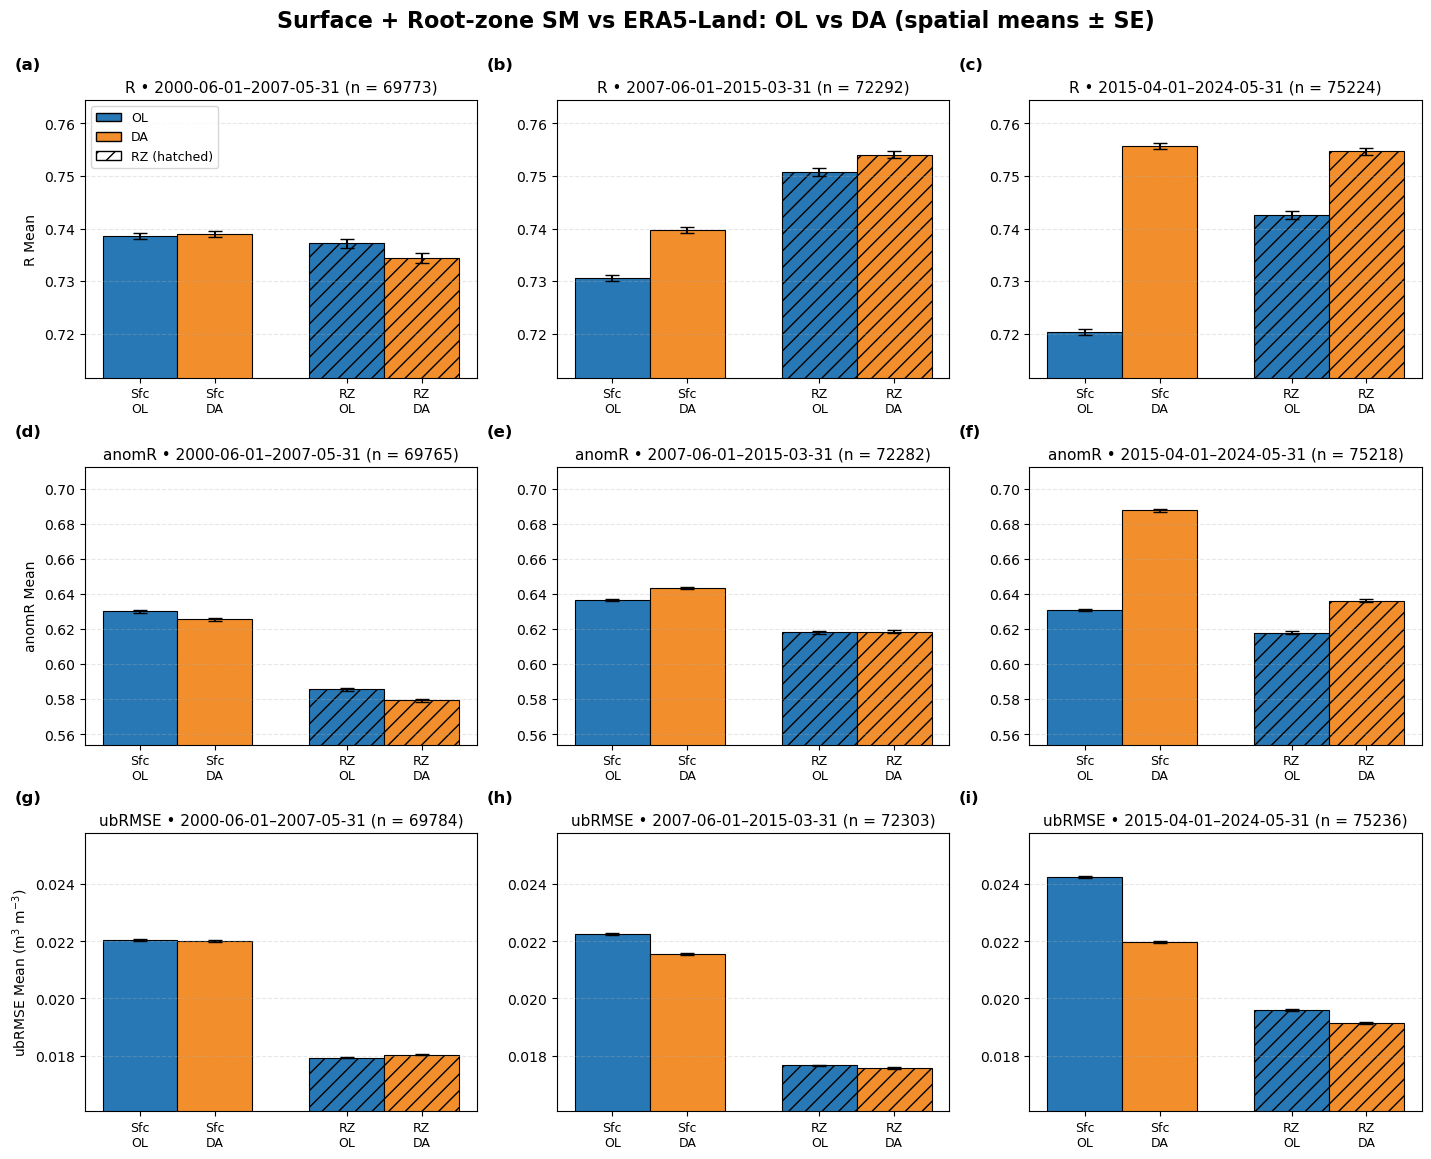

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_surface_rz_sm_combined_3x3_era5l_only.png


In [7]:
# --- Combined Surface + RZ SM bars in one 3x3 figure (same stats, ERA5-Land only) ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

if 'results' not in globals():
    raise RuntimeError('results not found. Run the periodized metrics cell first.')

period_subset = list(globals().get('sm_periods', all_periods[:3]))
print('Using SM periods:', period_subset)

# row spec: (title, surface_field, rz_field, y_label, hard_bounds)
row_specs = [
    ('R', 'R_sfc', 'R_rz', 'R Mean', (0.0, 1.0)),
    ('anomR', 'anomR_sfc', 'anomR_rz', 'anomR Mean', (0.0, 1.0)),
    ('ubRMSE', 'ubRMSE_sfc', 'ubRMSE_rz', 'ubRMSE Mean (m$^3$ m$^{-3}$)', (None, None)),
]


def _collect_metric(metric_key, periods):
    out = {str(p): {} for p in periods}
    for fn, ds_all in results.items():
        tag = label_for[fn]  # OL or DA
        for per in periods:
            if metric_key not in ds_all:
                out[str(per)][tag] = (np.nan, np.nan, 0)
            else:
                out[str(per)][tag] = mean_se_2d(ds_all[metric_key].sel(period=per))
    return out


fig, axes = plt.subplots(3, 3, figsize=(14.2, 11.0), constrained_layout=True)
fig.suptitle('Surface + Root-zone SM vs ERA5-Land: OL vs DA (spatial means ± SE)', fontsize=16, weight='bold', y=1.04)

# Precompute common y-lims per row across all periods and all 4 bars
row_lims = []
for _, sfc_key, rz_key, _, hard in row_specs:
    S_sfc = _collect_metric(sfc_key, period_subset)
    S_rz = _collect_metric(rz_key, period_subset)
    vals = []
    for per in period_subset:
        for tag in ('OL', 'DA'):
            vals.append(S_sfc[str(per)][tag][:2])
            vals.append(S_rz[str(per)][tag][:2])
    row_lims.append(pooled_ylim(vals, pad=0.22, hard=hard))

for r, (metric_title, sfc_key, rz_key, ylab, _) in enumerate(row_specs):
    S_sfc = _collect_metric(sfc_key, period_subset)
    S_rz = _collect_metric(rz_key, period_subset)

    for c, per in enumerate(period_subset):
        ax = axes[r, c]

        sfc_ol = S_sfc[str(per)]['OL']
        sfc_da = S_sfc[str(per)]['DA']
        rz_ol = S_rz[str(per)]['OL']
        rz_da = S_rz[str(per)]['DA']

        means = [sfc_ol[0], sfc_da[0], rz_ol[0], rz_da[0]]
        errs = [sfc_ol[1], sfc_da[1], rz_ol[1], rz_da[1]]

        # n shown as minimum valid count across all four bars in panel
        ns = [sfc_ol[2], sfc_da[2], rz_ol[2], rz_da[2]]

        bar_w = 0.72
        pair_gap = 0.55  # gap between Surface pair and RZ pair
        x = np.array([0.0, bar_w, 2*bar_w + pair_gap, 3*bar_w + pair_gap], dtype=float)
        bars = ax.bar(
            x,
            means,
            width=bar_w,
            color=[COL_OL, COL_DA, COL_OL, COL_DA],
            edgecolor='black',
            linewidth=0.8,
            yerr=errs,
            capsize=5,
        )

        # Hatch RZ bars to distinguish Surface vs RZ while keeping OL/DA colors.
        bars[2].set_hatch('//')
        bars[3].set_hatch('//')

        ax.set_xticks(x)
        ax.set_xticklabels(['Sfc\nOL', 'Sfc\nDA', 'RZ\nOL', 'RZ\nDA'], fontsize=9)
        ax.set_ylim(*row_lims[r])
        ax.grid(axis='y', alpha=0.30, linestyle='--')
        ax.set_title(f'{metric_title} • {per} (n = {int(np.nanmin(ns)) if np.isfinite(np.nanmin(ns)) else 0})', fontsize=11)
        panel_idx = r * len(period_subset) + c
        ax.text(-0.18, 1.10, f'({chr(97 + panel_idx)})', transform=ax.transAxes,
                ha='left', va='bottom', fontsize=12, fontweight='bold', clip_on=False)

        if c == 0:
            ax.set_ylabel(ylab)

        if r == 0 and c == 0:
            legend_handles = [
                Patch(facecolor=COL_OL, edgecolor='black', label='OL'),
                Patch(facecolor=COL_DA, edgecolor='black', label='DA'),
                Patch(facecolor='white', edgecolor='black', hatch='//', label='RZ (hatched)'),
            ]
            ax.legend(handles=legend_handles, loc='upper left', fontsize=9, frameon=True)

out_png = FIG_DIR / 'bars_surface_rz_sm_combined_3x3_era5l_only.png'
fig.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_png)



Using snow period: 2000-06-01–2024-05-31


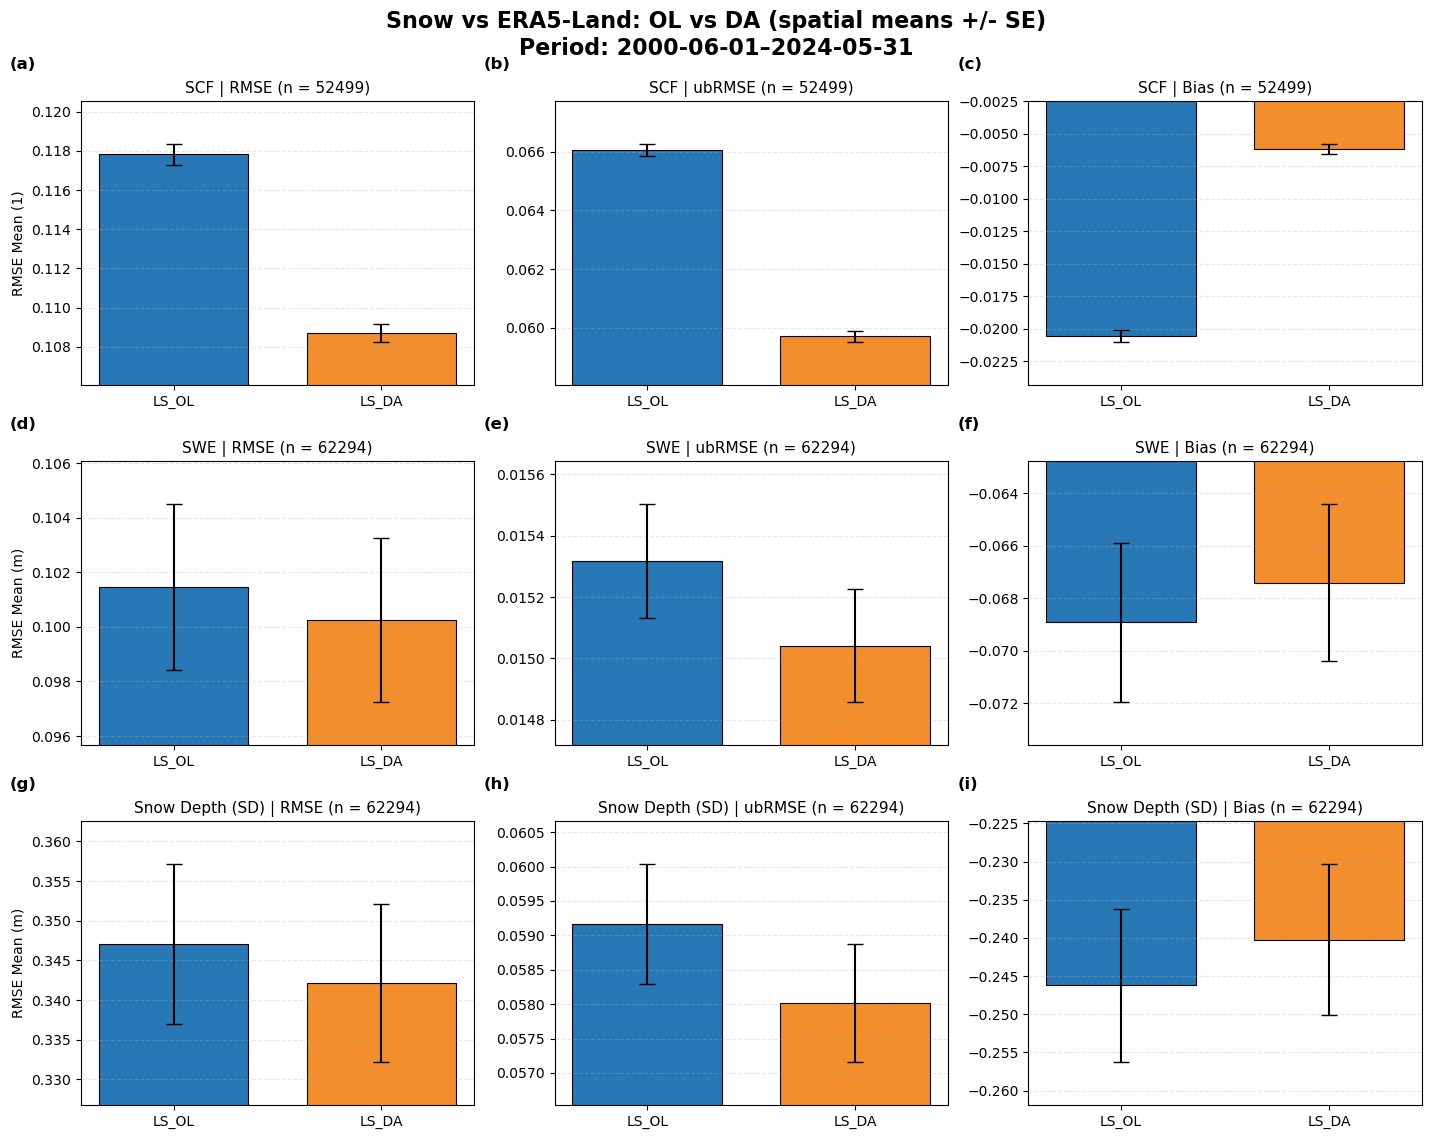

Saved: /Users/amfox/Desktop/geosldas-analysis/projects/era5_land/notebooks/figures_era5l_bars/bars_snow_combined_3x3_era5l_only.png


In [9]:
# --- Combined snow bars: 3x3 (rows=SCF/SWE/SD, cols=stats), ERA5-Land only ---
import numpy as np
import matplotlib.pyplot as plt

if 'results' not in globals():
    raise RuntimeError('results not found. Run the periodized metrics cell first.')

snow_per = snow_periods[0] if len(snow_periods) else full_period
print('Using snow period:', snow_per)

snow_rows = [
    ('SCF', {
        'RMSE': ('rmse_scf', 'RMSE Mean (1)'),
        'ubRMSE': ('ubRMSE_scf', 'ubRMSE Mean (1)'),
        'Bias': ('bias_scf', 'Bias Mean (1)'),
    }),
    ('SWE', {
        'RMSE': ('rmse_swe', 'RMSE Mean (m)'),
        'ubRMSE': ('ubRMSE_swe', 'ubRMSE Mean (m)'),
        'Bias': ('bias_swe', 'Bias Mean (m)'),
    }),
    ('Snow Depth (SD)', {
        'RMSE': ('rmse_snwd', 'RMSE Mean (m)'),
        'ubRMSE': ('ubRMSE_snwd', 'ubRMSE Mean (m)'),
        'Bias': ('bias_snwd', 'Bias Mean (m)'),
    }),
]

col_names = ['RMSE', 'ubRMSE', 'Bias']

fig, axes = plt.subplots(3, 3, figsize=(14.2, 10.8), constrained_layout=True)
fig.suptitle(
    f'Snow vs ERA5-Land: OL vs DA (spatial means +/- SE)\nPeriod: {snow_per}',
    fontsize=16,
    weight='bold',
    y=1.04,
)

for r, (row_name, col_map) in enumerate(snow_rows):
    for c, col_name in enumerate(col_names):
        ax = axes[r, c]
        mkey, ylabel = col_map[col_name]

        S = collect_stats(mkey, [snow_per])
        ol_mean, ol_se, ol_n = S[str(snow_per)]['OL']
        da_mean, da_se, da_n = S[str(snow_per)]['DA']

        means = [ol_mean, da_mean]
        errs = [ol_se, da_se]
        ns = [ol_n, da_n]

        x = np.arange(2, dtype=float)
        ax.bar(
            x,
            means,
            width=0.72,
            color=[COL_OL, COL_DA],
            edgecolor='black',
            linewidth=0.8,
            yerr=errs,
            capsize=6,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(['LS_OL', 'LS_DA'])
        ax.set_ylim(*pooled_ylim([(ol_mean, ol_se), (da_mean, da_se)], pad=0.22, hard=(None, None)))
        ax.grid(axis='y', alpha=0.30, linestyle='--')
        ax.set_title(f'{row_name} | {col_name} (n = {min(ns)})', fontsize=11)

        if c == 0:
            ax.set_ylabel(ylabel)

        panel_idx = r * len(col_names) + c
        ax.text(
            -0.18,
            1.10,
            f'({chr(97 + panel_idx)})',
            transform=ax.transAxes,
            ha='left',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            clip_on=False,
        )

out_png = FIG_DIR / 'bars_snow_combined_3x3_era5l_only.png'
fig.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', out_png)
